In [1]:
import pandas as pd
from autogluon.tabular import TabularPredictor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_curve, auc
import shap
import os
import shutil

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np
import torch
# Ensure PyTorch utilizes CUDA for neural network models in the ensemble
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [3]:
from feature_engineering import *

In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [5]:
df_train=pd.read_csv('../data/train.csv')
df_test=pd.read_csv('../data/test.csv')
df_train_merged = pd.read_csv('../data/train_merged.csv')
df_sampling_test = pd.read_csv("../external/Sampling_merged.csv")

In [6]:
df_fe_train=set_fe(df_train)
df_fe_test=set_fe(df_test)
df_fe_train_merged = set_fe(df_train_merged)
df_fe_sampling_test = set_fe(df_sampling_test)

In [7]:


def add_group_factors(
    df: pd.DataFrame,
    df_train_merged: pd.DataFrame,
    group_cols: list[str],
    value_col: str = "TyreLife",
    suffix: str = ""
) -> pd.DataFrame:
    """
    Computes group aggregations on df_train_merged, converts metrics into dictionary 
    factors using multi-column tuple keys, and maps them to df.
    """
    df = df.copy()

    # 1. Compute group statistics
    stats_all = (
        df_train_merged.groupby(group_cols)[value_col]
        .agg(
            Stint_Count="count",
            Stint_Tyre_Mean_Life="mean",
            Stint_Tyre_Median_Life="median",
            Stint_Tyre_Min_Life="min",
            Stint_Tyre_Max_Life="max",
            Stint_Tyre_Std_Dev="std",
        )
        .reset_index()
    )

    stat_cols = ["Stint_Count", "Stint_Tyre_Mean_Life", "Stint_Tyre_Median_Life", "Stint_Tyre_Min_Life", "Stint_Tyre_Max_Life", "Stint_Tyre_Std_Dev"]

    # 2. Build tuple keys for multi-column matching
    if len(group_cols) == 1:
        keys = df[group_cols[0]]
    else:
        keys = list(zip(*[df[col] for col in group_cols]))

    # 3. Create dictionary factor for each stat and map to main DF
    for col in stat_cols:
        factor_dict = stats_all.set_index(group_cols)[col].to_dict()
        
        target_col_name = f"{col}{suffix}"
        if len(group_cols) == 1:
            df[target_col_name] = df[group_cols[0]].map(factor_dict)
        else:
            df[target_col_name] = [factor_dict.get(k) for k in keys]

    return df

def feature_engineering_v6(df,df_train_merged):
    # 1. Compute group statistics
    group_columns = ["Stint", "Compound", "Year"]

    # Map all statistical factors from df_external into df
    df = add_group_factors(
        df=df,
        df_train_merged=df_train_merged,
        group_cols=group_columns,
        value_col="TyreLife"
    )
    return df

In [21]:
df_fe_train =feature_engineering_v6(df_fe_train,df_fe_train_merged)
df_train_merged_fe =feature_engineering_v6(df_fe_train_merged,df_fe_train_merged)
df_fe_test =feature_engineering_v6(df_fe_test,df_fe_train_merged)
df_fe_sampling_test = feature_engineering_v6(df_fe_sampling_test,df_fe_train_merged)

In [22]:
#optional
def calculate_race_progress(df):
    condition = (df["Race"] == "Pre-Season Testing") & (
        (df["RaceLaps"] < 31) | (df["RaceLaps"] > 78)
    )

    # Keep rows that do NOT match the condition
    df = df[~condition] 
    F1_RACE_LAPS = {
        "Bahrain Grand Prix": 57,
        "Saudi Arabian Grand Prix": 50,
        "Australian Grand Prix": 58,
        "Azerbaijan Grand Prix": 51,
        "Miami Grand Prix": 57,
        "Monaco Grand Prix": 78,
        "Spanish Grand Prix": 66,
        "Canadian Grand Prix": 70,
        "Austrian Grand Prix": 71,
        "British Grand Prix": 52,
        "Hungarian Grand Prix": 70,
        "Belgian Grand Prix": 44,
        "Dutch Grand Prix": 72,
        "Italian Grand Prix": 51,
        "Singapore Grand Prix": 62,
        "Japanese Grand Prix": 53,
        "Qatar Grand Prix": 57,
        "United States Grand Prix": 56,
        "Mexico City Grand Prix": 71,
        "São Paulo Grand Prix": 71,
        "Las Vegas Grand Prix": 50,
        "Abu Dhabi Grand Prix": 58,
        }
    mask = df["Race"].isin(F1_RACE_LAPS.keys())

    # Update only matching rows
    df.loc[mask, "RaceLaps"] = df.loc[mask, "Race"].map(F1_RACE_LAPS)
    df["RaceLaps"] = df["Race"].map(F1_RACE_LAPS)
    df["RaceProgress"] = df["LapNumber"] / df["RaceLaps"]
    df["LapsRemaining"] = df["RaceLaps"] - df["LapNumber"]
    return df


# df_fe_train =calculate_race_progress(df_fe_train)
# df_train_merged_fe =calculate_race_progress(df_fe_train_merged)
# df_fe_test =calculate_race_progress(df_fe_test)
# df_fe_sampling_test = calculate_race_progress(df_sampling_test)

In [23]:
TARGET = 'PitNextLap'

In [24]:
df_fe_sampling_test=df_fe_sampling_test.rename({"ground_truth":TARGET},axis=1)

In [34]:
model_name ="ag_models23"

In [26]:
def feature_importance_for_each_model(predictor,df_test, model_name, model_val_path):
    model_feature_importances = {}

    for model_name in predictor.model_names():
        # Limit subsample_size for faster execution if you have many models
        fi = predictor.feature_importance(
            data=df_test,
            model=model_name,
            subsample_size=1000,
            silent=True
        )
        model_feature_importances[model_name] = fi['importance']

    # Combine into a single comparison DataFrame
    df_fi_comparison = pd.DataFrame(model_feature_importances)
    top_features = (
    df_fi_comparison.mean(axis=1).sort_values(ascending=False).head(15).index
    )
    df_fi_top = df_fi_comparison.loc[top_features]

    plt.figure(figsize=(12, 8))
    sns.heatmap(
        df_fi_top,
        annot=True,
        fmt=".4f",
        cmap="YlGnBu",
        cbar_kws={"label": "Importance (Drop in ROC-AUC)"},
        linewidths=0.5,
    )

    plt.title(
        "Feature Importance Comparison Across All Models",
        fontsize=14,
        fontweight="bold",
        pad=15,
    )
    plt.xlabel("Model Name", fontsize=12)
    plt.ylabel("Feature Name", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    
    plt.tight_layout()
    plt.savefig(f"{model_val_path}/feature_mportance_accross_models.png", dpi=300, bbox_inches="tight")
    plt.show()

    top_10_features = (
        df_fi_comparison.mean(axis=1).sort_values(ascending=False).head(10).index
    )
    df_fi_melted = (
        df_fi_comparison.loc[top_10_features]
        .reset_index()
        .melt(id_vars="index", var_name="Model", value_name="Importance")
    )
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df_fi_melted,
        x="Importance",
        y="index",
        hue="Model",
        palette="tab10",
        edgecolor="black",
    )
    
    plt.title(
        "Top 10 Feature Importances Across All Models",
        fontsize=14,
        fontweight="bold",
        pad=15,
    )
    plt.xlabel("Importance (ROC-AUC drop)", fontsize=12)
    plt.ylabel("Feature", fontsize=12)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(axis="x", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"{model_val_path}/top_10_feature_mportance_accross_models.png", dpi=300, bbox_inches="tight")
    plt.show()

In [27]:
def individual_model_ruc(predictor, df_test, model_val_path, TARGET = "PitNextLap"):
    # Plot ROC Curves for All Models Side-by-Side
    
    plt.figure(figsize=(10, 7))

    for model_name in predictor.model_names():
        y_proba = predictor.predict_proba(df_test, model=model_name)[1]
        fpr, tpr, _ = roc_curve(df_test[TARGET], y_proba)
        roc_auc = auc(fpr, tpr)
        
        # Highlight the best model with a thicker line
        if model_name == predictor.model_best:
            plt.plot(fpr, tpr, label=f"{model_name} (BEST: AUC = {roc_auc:.4f})", linewidth=3, color="black")
        else:
            plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.4f})", alpha=0.7, linestyle="--")

    plt.plot([0, 1], [0, 1], "k:", label="Random Chance")
    plt.title("ROC Curves for All Trained Models", fontsize=14, fontweight="bold")
    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"{model_val_path}/model_individual_ruc.png", dpi=300, bbox_inches="tight")
    plt.show()

In [28]:
def prediction_impacts(predictor,df_test, model_val_path,TARGET = "PitNextLap"):
    X_val = df_test.drop(columns=[TARGET])
    test_samples = X_val.sample(n=min(30, len(X_val)), random_state=42)
    background_data = shap.sample(X_val, 10)


    # 2. Direct AutoGluon predict_proba wrapper
    def predict_fn(x):
        if not isinstance(x, pd.DataFrame):
            x = pd.DataFrame(x, columns=test_samples.columns)
        return predictor.predict_proba(x)[1].values


    # 3. Run KernelExplainer
    explainer = shap.KernelExplainer(predict_fn, background_data)
    raw_shap_values = explainer.shap_values(test_samples)

    shap_explanation = shap.Explanation(
    values=raw_shap_values,
    base_values=explainer.expected_value,
    data=test_samples.values,
    feature_names=test_samples.columns,
    )

    # 5. Global Beeswarm Plot
    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
    plt.title(
        "Global Feature Impact (SHAP Beeswarm)",
        fontsize=14,
        fontweight="bold",
        pad=15,
    )
    plt.tight_layout()
    plt.savefig(f"{model_val_path}/global_prediction_impacts.png", dpi=300, bbox_inches="tight")
    plt.show()




    # 6. Local Waterfall Plot (First Sample)
    plt.figure(figsize=(8, 6))
    shap.plots.waterfall(shap_explanation[0], show=False)
    plt.title(
        "Local Prediction Explanation (Sample #1)",
        fontsize=14,
        fontweight="bold",
        pad=15,
    )
    plt.tight_layout()
    plt.savefig(f"{model_val_path}/local_feature_pred_explaination.png", dpi=300, bbox_inches="tight")
    plt.show()

In [29]:
def get_roc_curve(predictor, df_test, model_val_path, TARGET = "PitNextLap"):
    y_true = df_test[TARGET]
    y_probs = predictor.predict_proba(df_test)[1]
    y_preds = predictor.predict(df_test)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    # ROC Curve
    roc = RocCurveDisplay.from_predictions(
        y_true,
        y_probs,
        ax=axes[0],
        name="AutoGluon Ensemble"
    )

    roc.line_.set_color("#1f77b4")
    axes[0].plot([0, 1], [0, 1], "k--", label="Random Chance (AUC = 0.5)")
    axes[0].set_title("ROC-AUC Curve", fontsize=13, fontweight="bold")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[0].legend()

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_true, y_preds, ax=axes[1], cmap="Blues")
    axes[1].set_title("Confusion Matrix", fontsize=13, fontweight="bold")

    plt.tight_layout()
    plt.savefig(f"{model_val_path}/confusion_mtrix_entire_model.png", dpi=300, bbox_inches="tight")
    plt.show()

In [30]:
def plot_leaderboard_graph(predictor,df_test, model_val_path):
    leaderboard = predictor.leaderboard(
    data=df_test.head(10000), silent=False, extra_info=True  # Set True to see hyperparameters per model
)
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        x="score_val",
        y="model",
        data=leaderboard,
        palette="mako",
        edgecolor="black",
    )

    # Highlight best model score
    best_score = leaderboard["score_val"].max()
    plt.axvline(best_score, color="red", linestyle="--", label=f"Best ({best_score:.4f})")

    plt.xlim(left=max(0, leaderboard["score_val"].min() - 0.02))
    plt.title("AutoGluon Model Performance Leaderboard", fontsize=14, fontweight="bold")
    plt.xlabel("Validation ROC-AUC", fontsize=12)
    plt.ylabel("Model Name", fontsize=12)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f"{model_val_path}/plot_leaderboard_graph.png", dpi=300, bbox_inches="tight")
    plt.show()

In [31]:
def plot_feature_importance_graph(feature_importance, model_val_path):
    top_fi = feature_importance.head(20).reset_index()

    plt.figure(figsize=(10, 6))
    bars = plt.barh(
        y=top_fi["index"],
        width=top_fi["importance"],
        xerr=top_fi["stddev"],
        capsize=4,
        color="#2b5c8f",
        edgecolor="black",
    )

    plt.gca().invert_yaxis()  # Highest importance at top
    plt.title("Top 20 Feature Importances (Permutation Drop in ROC-AUC)", fontsize=14, fontweight="bold")
    plt.xlabel("Importance (Decrease in ROC-AUC)", fontsize=12)
    plt.ylabel("Feature", fontsize=12)
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"{model_val_path}/plot_feature_importance_graph.png", dpi=300, bbox_inches="tight")
    plt.show()

In [32]:
def model_analysis(model_name, df_test):
    model_val_path = f"{model_name}_validations"
    if os.path.exists(model_val_path):
        print(f"Deleting existing model directory: {model_val_path}")
        shutil.rmtree(model_val_path)

    os.makedirs(model_val_path, exist_ok=True)
    
    df_test=df_test.head(10000)
    predictor = TabularPredictor.load(f"../{model_name}")
    predictor.info()
    print("Leader Board")
    leaderboard = predictor.leaderboard(silent=True).to_string(index=False)
    print(leaderboard)

    print("Leaderboard graph")
    plot_leaderboard_graph(predictor, df_test, model_val_path)
    
    feature_importance = predictor.feature_importance(
    data=df_test,  # Or test_data
    subsample_size=10000,  # Limits sample size for speed (increase or set to None for higher precision)
    num_shuffle_sets=5,  # Number of times to shuffle each feature to reduce variance
    )
    
    print("Feature Importance graph")
    plot_feature_importance_graph(feature_importance, model_val_path)
    print("Modal ROC CURVE")
    get_roc_curve(predictor, df_test,model_val_path, TARGET = "PitNextLap")
    print("prediction_impacts")
    prediction_impacts(predictor,df_test,model_val_path,TARGET = "PitNextLap")
    print("individual_model_ruc")
    individual_model_ruc(predictor, df_test,model_val_path, TARGET = "PitNextLap")
    print("feature_importance_for_each_model")
    feature_importance_for_each_model(predictor=predictor,df_test=df_test,model_val_path=model_val_path,model_name=model_name)


Leader Board
               model  score_val eval_metric  pred_time_val    fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
 WeightedEnsemble_L2   0.959460     roc_auc      37.851774 1465.858844                0.049511           5.048708            2       True          5
     LightGBM_BAG_L1   0.958582     roc_auc      11.585326  237.785779               11.585326         237.785779            1       True          1
      XGBoost_BAG_L1   0.957616     roc_auc       3.208460  316.089861                3.208460         316.089861            1       True          4
LightGBMLarge_BAG_L1   0.957466     roc_auc      22.577827  311.292773               22.577827         311.292773            1       True          2
     CatBoost_BAG_L1   0.955343     roc_auc       0.430650  595.641723                0.430650         595.641723            1       True          3
Leaderboard graph
                  model  score_test  score_val eval_metric  pred_time_test 

C:\Users\Admin\AppData\Local\Temp\ipykernel_12624\398911894.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


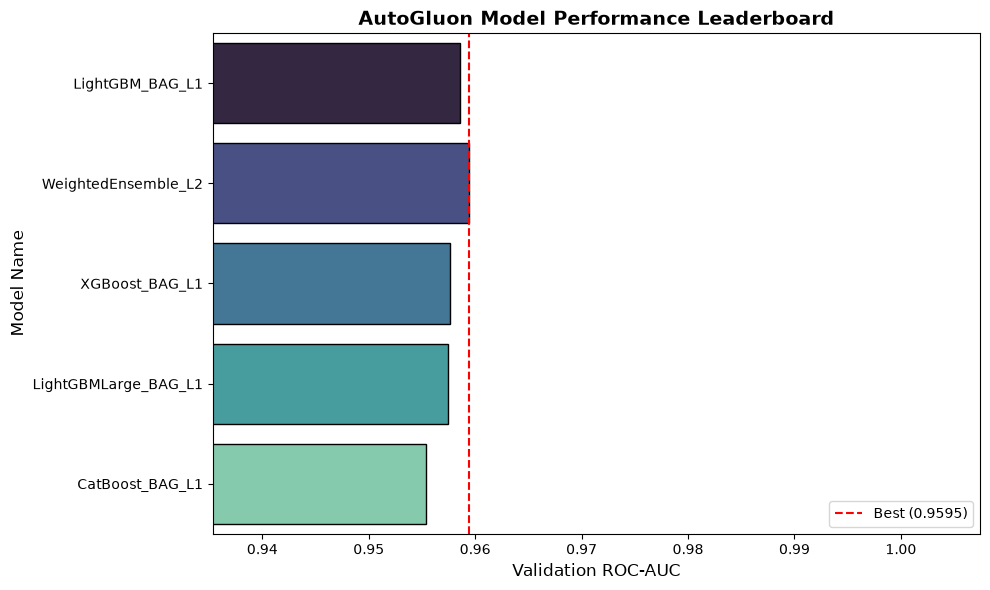

These features in provided data are not utilized by the predictor and will be ignored: ['Driver']


Feature Importance graph


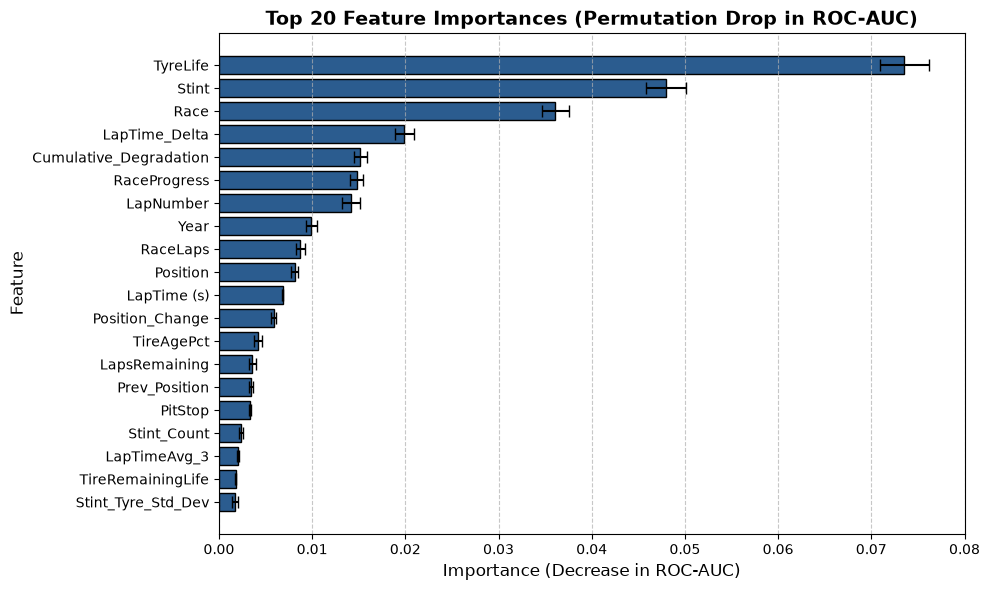

Modal ROC CURVE


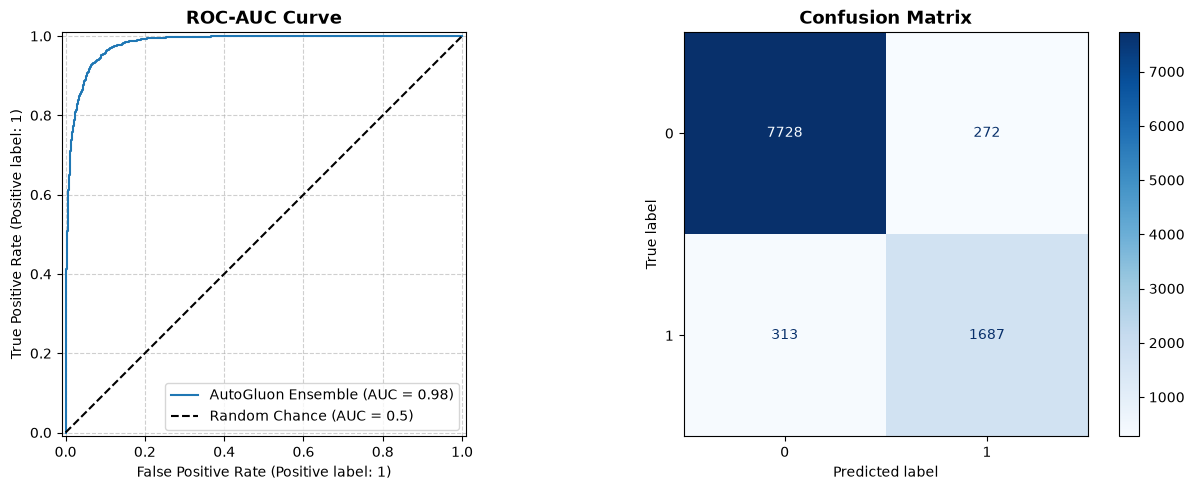

prediction_impacts


100%|██████████| 30/30 [07:12<00:00, 14.41s/it]


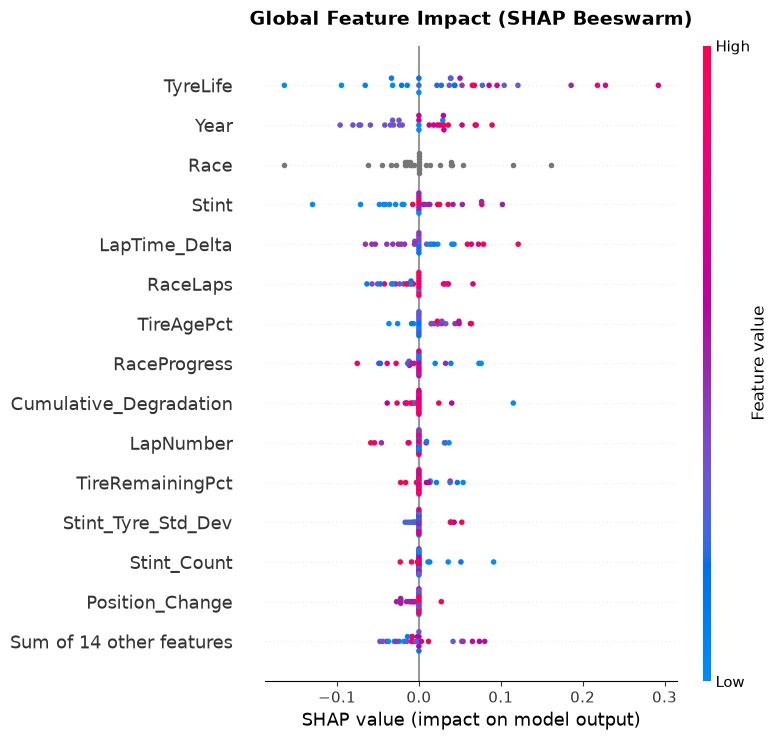

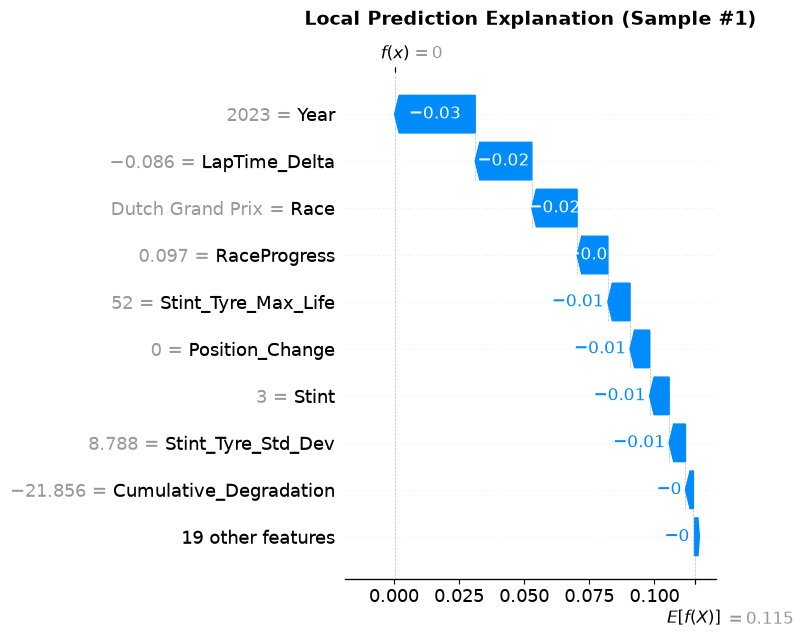

individual_model_ruc


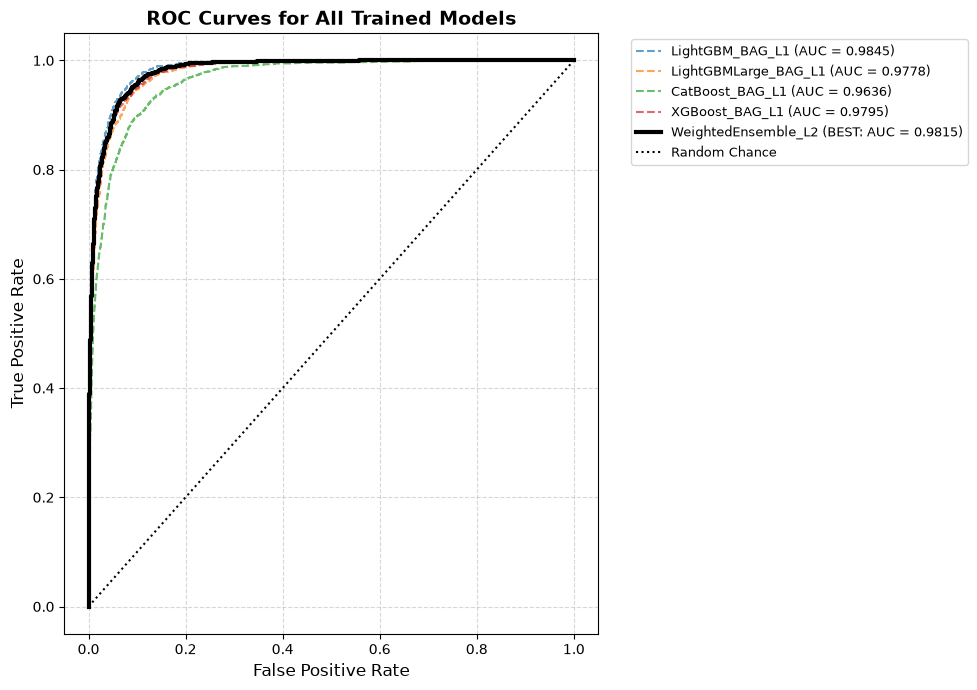

These features in provided data are not utilized by the predictor and will be ignored: ['Driver']


feature_importance_for_each_model


These features in provided data are not utilized by the predictor and will be ignored: ['Driver']
These features in provided data are not utilized by the predictor and will be ignored: ['Driver']
These features in provided data are not utilized by the predictor and will be ignored: ['Driver']
These features in provided data are not utilized by the predictor and will be ignored: ['Driver']


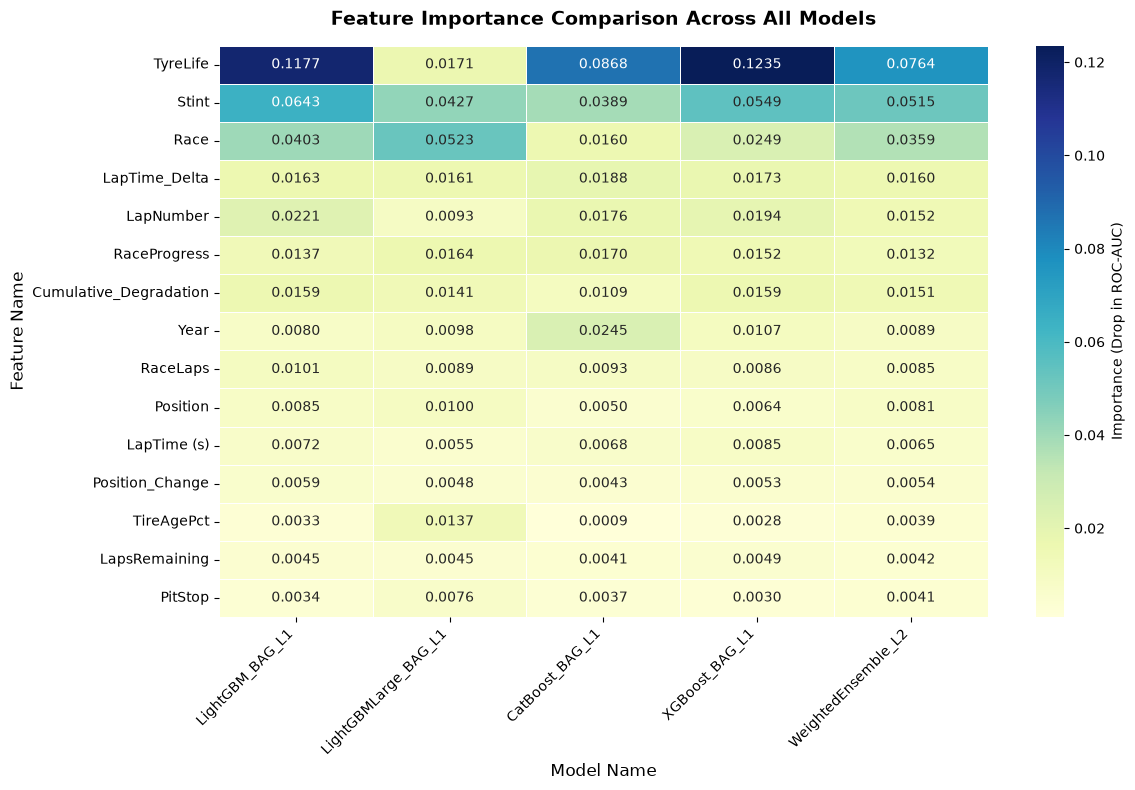

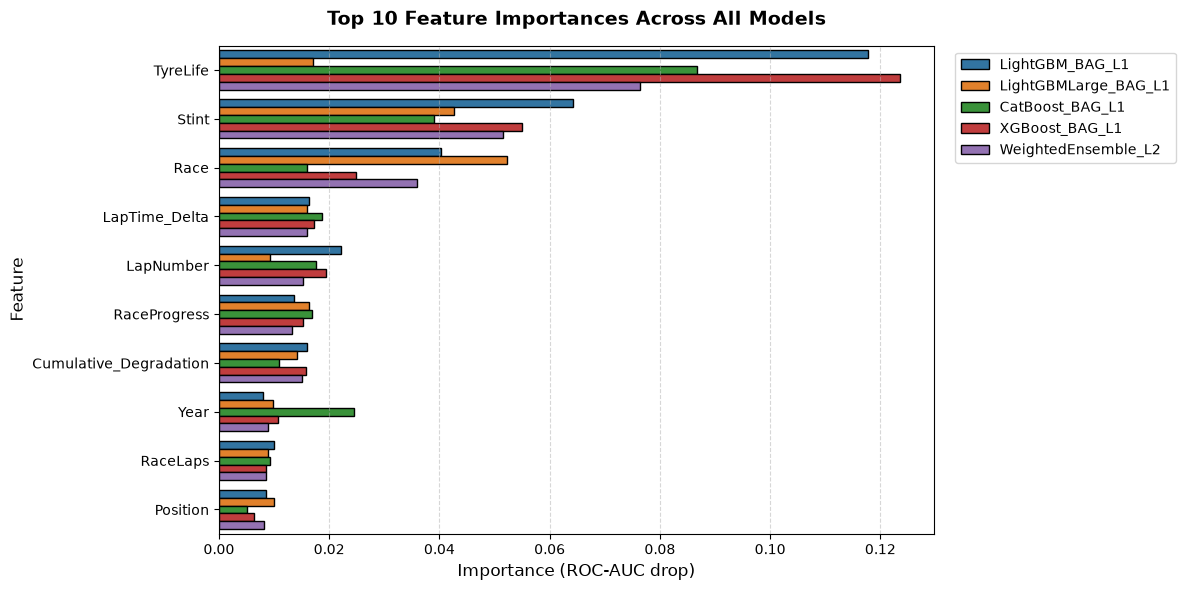

In [35]:
model_analysis(model_name, df_fe_sampling_test)